
# **Chest X-Ray Diagnosis Analysis with MapReduce and Image Visualizations**

This notebook performs diagnosis frequency analysis using a MapReduce-style approach, and visualizes the results using bar chart, pie chart, and sample image analysis.


In [2]:

!pip install pandas matplotlib seaborn pillow requests


In [ ]:
!pip install scikit-learn pandas numpy

# **Import Packages**

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import requests
from io import BytesIO
from PIL import Image


# **Importing Data**

In [4]:

csv_url = "https://raw.githubusercontent.com/Sakhile16/CXR/main/CXR_Selected-Image-Dataset_Log.csv"
df = pd.read_csv(csv_url)
df.head()


,Type,Dataset,File Number,Old File Name,New File Name,Old File Extenstion,New File Extension
0,Pneumonia,Darwin,00006431,00006431_covid-19-pneumonia-21.png,DARCXR_00006431.png,png,png
1,Pneumonia,Darwin,00006804,00006804_aspiration-pneumonia-5-day0.png,DARCXR_00006804.png,png,png
2,Pneumonia,Darwin,00006805,00006805_aspiration-pneumonia-5-day3.png,DARCXR_00006805.png,png,png
3,Pneumonia,Darwin,00006806,00006806_aspiration-pneumonia-5-day10.png,DARCXR_00006806.png,png,png
4,Pneumonia,Darwin,00006807,00006807_aspiration-pneumonia-5-day27.png,DARCXR_00006807.png,png,png


# **MapReduce**

In [5]:

def mapper(data):
    mapped = []
    for label in data['Type'].dropna():
        mapped.append((label, 1))
    return mapped

def reducer(mapped_data):
    counter = Counter()
    for label, count in mapped_data:
        counter[label] += count
    return counter

mapped = mapper(df)
reduced = reducer(mapped)
diagnosis_df = pd.DataFrame(reduced.items(), columns=['Diagnosis', 'Count']).sort_values(by='Count', ascending=False)
diagnosis_df.reset_index(drop=True, inplace=True)
diagnosis_df


,Diagnosis,Count
0,No Opacity Not Normal,11821
1,Normal,11350
2,Pneumonia,10376


# **Visualization**

#Bar Chart

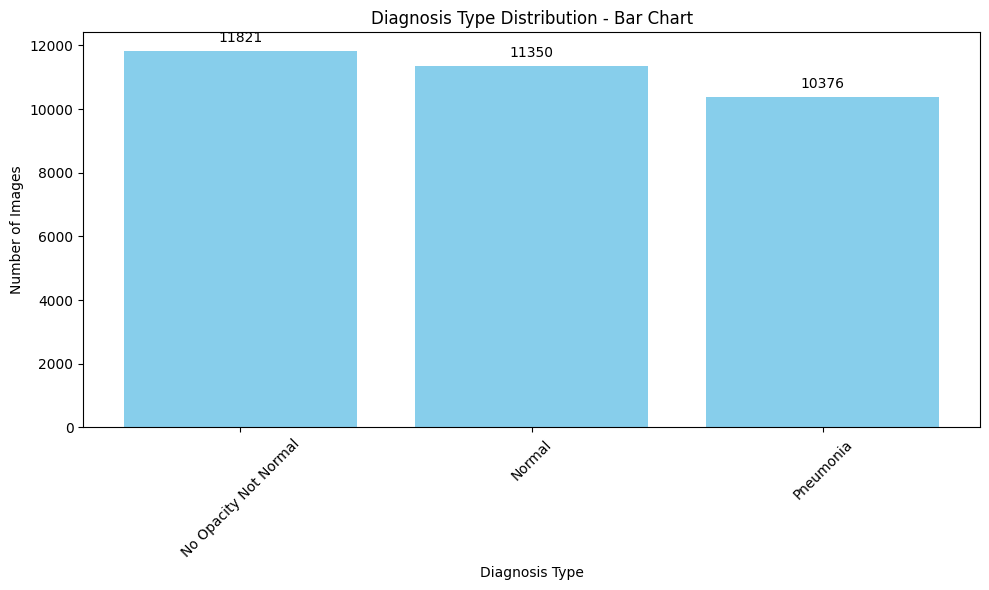

In [10]:

plt.figure(figsize=(10, 6))
bars = plt.bar(diagnosis_df['Diagnosis'], diagnosis_df['Count'], color='skyblue')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 200, f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

plt.title("Diagnosis Type Distribution - Bar Chart")
plt.xlabel("Diagnosis Type")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



#Pie Chart

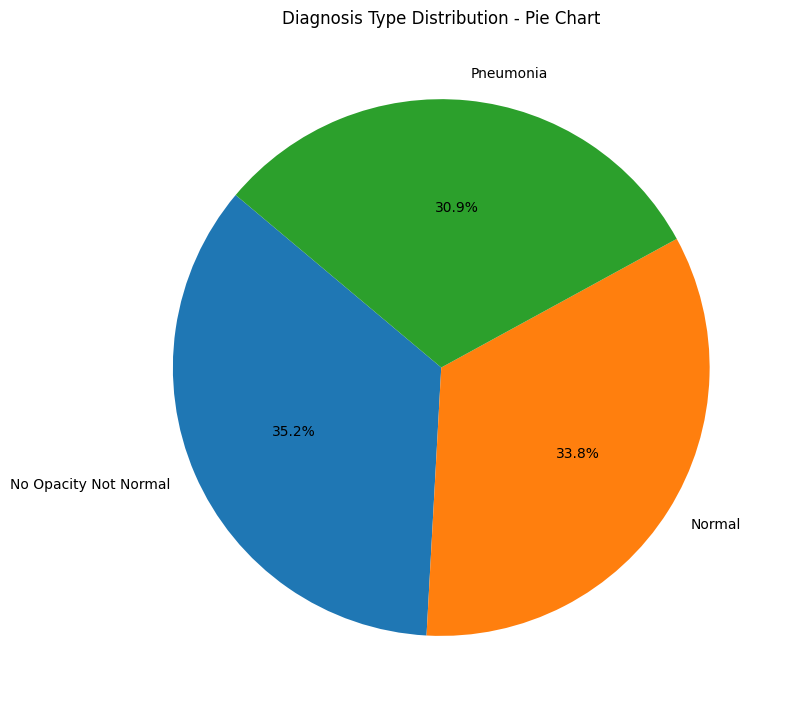

In [7]:

plt.figure(figsize=(8, 8))
plt.pie(diagnosis_df['Count'], labels=diagnosis_df['Diagnosis'], autopct='%1.1f%%', startangle=140)
plt.title("Diagnosis Type Distribution - Pie Chart")
plt.tight_layout()
plt.show()


# **Sample Images**

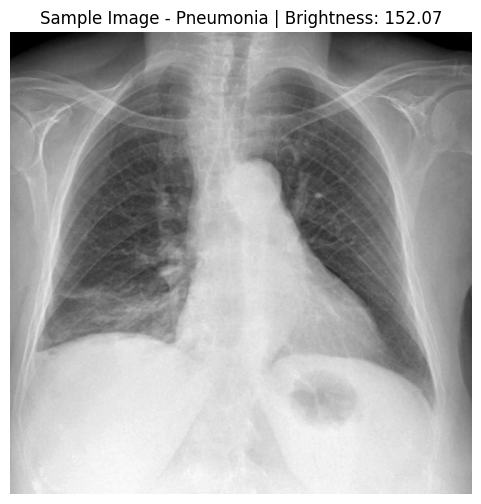

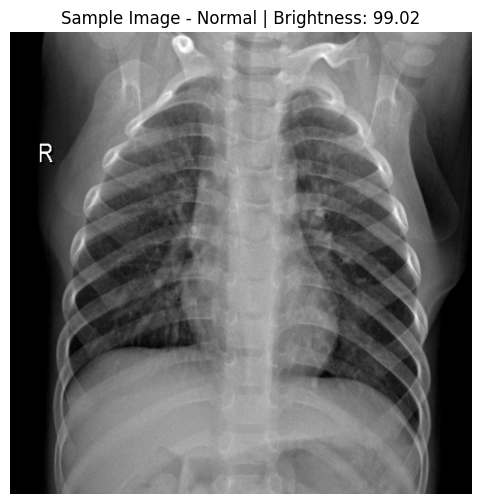

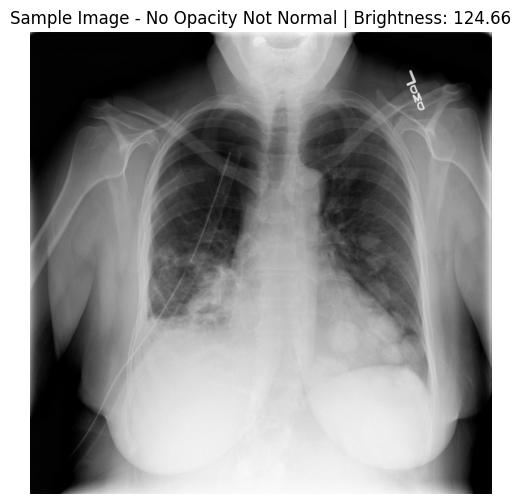

,Diagnosis,Avg Brightness
0,Pneumonia,152.07
1,Normal,99.02
2,No Opacity Not Normal,124.66


In [8]:

folder_mapping = {
    "Pneumonia": ["CXR_Pneumonia", "CXR_Pneumonia2", "CXR_Pneumonia3", "CXR_Pneumonia4"],
    "Normal": ["CXR_Normal", "CXR_Normal2", "CXR_Normal3", "CXR_Normal4"],
    "No Opacity Not Normal": ["CXR_No_Opacity_Not_Normal", "CXR_No_Opacity_Not_Normal2", "CXR_No_Opacity_Not_Normal3", "CXR_No_Opacity_Not_Normal4"]
}

brightness_stats = {}

for diagnosis, folders in folder_mapping.items():
    sample_row = df[df['Type'] == diagnosis].iloc[0]
    image_name = sample_row['New File Name']
    found = False
    for folder in folders:
        image_url = f"https://raw.githubusercontent.com/Sakhile16/CXR/main/{folder}/{image_name}"
        try:
            response = requests.get(image_url)
            if response.status_code == 200:
                img = Image.open(BytesIO(response.content)).convert('L')
                brightness = sum(img.getdata()) / (img.size[0] * img.size[1])
                brightness_stats[diagnosis] = round(brightness, 2)
                plt.figure(figsize=(6, 6))
                plt.imshow(img, cmap='gray')
                plt.axis('off')
                plt.title (f"Sample Image - {diagnosis} | Brightness: {brightness:.2f}")
                plt.show()
                found = True
                break
        except Exception:
            continue
    if not found:
        print(f"Image not found for {diagnosis}: {image_name}")

pd.DataFrame(list(brightness_stats.items()), columns=['Diagnosis', 'Avg Brightness'])


# Simulate Diagnostic Dataset
We simulate a dataset based on image counts for three diagnosis types: No Opacity Not Normal, Normal, and Pneumonia.

In [13]:

labels = ['No Opacity Not Normal'] * 11821 + ['Normal'] * 11350 + ['Pneumonia'] * 10376
np.random.seed(42)
features = np.random.rand(len(labels), 10)
df_model = pd.DataFrame(features, columns=[f'feature_{i}' for i in range(10)])
df_model['label'] = labels

# Encode Labels and Split Dataset

In [14]:

df_model['label_encoded'] = df_model['label'].astype('category').cat.codes
X = df_model.drop(['label', 'label_encoded'], axis=1)
y = df_model['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Train Random Forest Classifier

In [15]:

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

# Evaluate Model Performance

In [16]:

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, target_names=df_model['label'].astype('category').cat.categories.tolist())
print("Diagnostic Classification Model Evaluation:")
print(report)


Diagnostic Classification Model Evaluation:
                       precision    recall  f1-score   support

No Opacity Not Normal       0.36      0.45      0.40      2381
               Normal       0.35      0.35      0.35      2260
            Pneumonia       0.31      0.21      0.25      2069

             accuracy                           0.34      6710
            macro avg       0.34      0.34      0.33      6710
         weighted avg       0.34      0.34      0.34      6710

